## **SIMULACIÓN | ENTREGABLE 1**
### ***HMM - Hidden Markov's Model para Análisis de Sentimientos***
[Aquí insertar participantes, descripción, objetivos y alcance]

In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display         # Librería IPython: Mostrar datos en Jupyter Notebook

In [2]:
df_FlexDrive_Emotions = pd.read_csv('../../../docs/poblaciones/dfFlexDrive_Cundiboyacense.csv', sep=';', encoding='utf-8')

## Definición: Distribución Inicial (π) para todo DF

C:\Users\leshi\AppData\Local\Temp\ipykernel_49372\2923958568.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["E", "Ne", "N", "Ni", "I"], y=distribucion, palette="viridis")


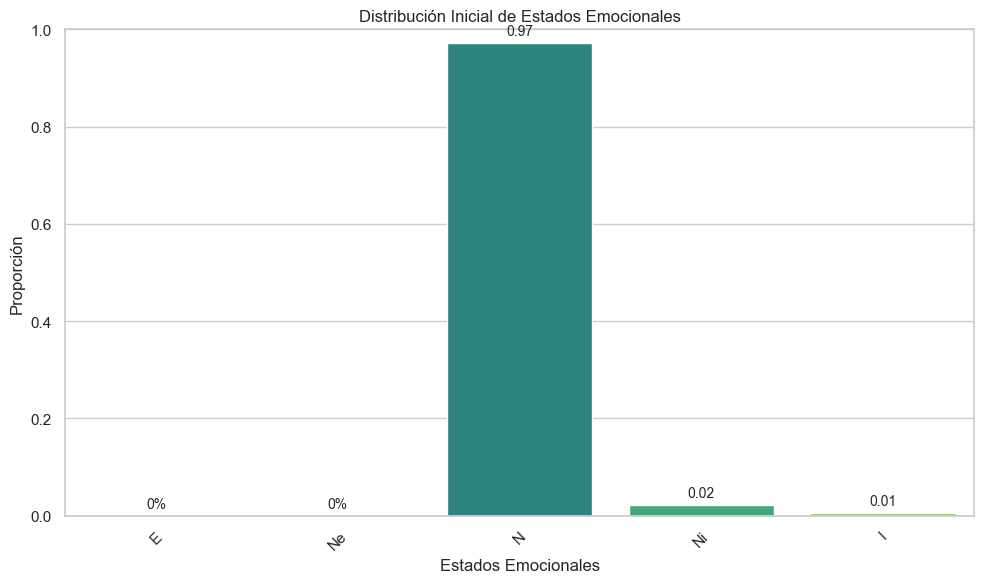

Distribución inicial: [0, 0, 0.9727272727272728, 0.02121212121212121, 0.006060606060606061]


In [3]:
def contiene(x, *valores):
    return all(v in x.split(';') for v in valores if isinstance(x, str))
    
def calcular_distribucion_inicial(df):
    len_df = len(df)
    
    # Inicializar distribución: E, Ne, N, Ni, I
    distribucion = [0, 0, 0, 0, 0]

    # Sanciones NI (Neutro-Indiferente)
    distribucion[3] += df["P4-Ciudad"].isna().sum() / len_df
    distribucion[3] += df["P7-Actividad_Actual_Multi"].isna().sum() / len_df

    # Estudiante de secundaria y universitario
    distribucion[3] += df["P7-Actividad_Actual_Multi"].apply(lambda x: contiene(x, "Estudiante de secundaria", "Universitario")).sum() / len_df
    # Empleado y desempleado
    distribucion[3] += df["P7-Actividad_Actual_Multi"].apply(lambda x: contiene(x, "Empleado", "Desempleado")).sum() / len_df
    # Est. secundaria y desempleado
    distribucion[3] += df["P7-Actividad_Actual_Multi"].apply(lambda x: contiene(x, "Estudiante de secundaria", "Desempleado")).sum() / len_df
    # Est. secundaria y jubilado
    distribucion[3] += df["P7-Actividad_Actual_Multi"].apply(lambda x: contiene(x, "Estudiante de secundaria", "Jubilado")).sum() / len_df

    # Edad temprana + Jubilado
    mask_edad_jubilado = (
        df["P2-Edad"].isin(["16-17", "18-25"]) &
        df["P7-Actividad_Actual_Multi"].fillna("").str.contains("Jubilado")
    )
    distribucion[3] += mask_edad_jubilado.sum() / len_df

    # Incoherencia: usa y no usa servicios públicos
    mask_p10_vs_p9 = (
        df["P10-Servicios_Públicos_Usados_Multi"].notna() &
        (df["P9-Frecuencia_Uso_Servicios_Públicos"] == "En ninguna ocasión.")
    )
    
    # Valores para Indiferente
    distribucion[4] += mask_p10_vs_p9.sum() / len_df  # I

    # Estado N = complemento
    distribucion[2] = 1 - sum(distribucion)

    # Visualización
    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 6))
    sns.barplot(x=["E", "Ne", "N", "Ni", "I"], y=distribucion, palette="viridis")

    # Etiquetas
    plt.title("Distribución Inicial de Estados Emocionales")
    plt.xlabel("Estados Emocionales")
    plt.ylabel("Proporción")
    plt.xticks(rotation=45)

    # Valores encima de barras
    for i, v in enumerate(distribucion):
        etiqueta = f"{v:.2f}" if v > 0 else "0%"
        plt.text(i, v + 0.01, etiqueta, ha='center', va='bottom', fontsize=10)

    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

    # Mostrar el array final
    print(f"Distribución inicial: {distribucion}")
    return np.array(distribucion)

# Calcular
distribucion_inicial = calcular_distribucion_inicial(df_FlexDrive_Emotions)


## Seguimiento: Pesos de Emociones y Asignación por Filas

In [4]:
# Puntaje y clasificación para conceptos positivos
def puntaje_FORM1(respuesta, pesos_estandar, pesos_con_otros, usar_otros):
    if pd.isna(respuesta):
        return 0.0
    pesos = pesos_con_otros if usar_otros else pesos_estandar
    opciones = [op.strip() for op in respuesta.split(';')]
    return sum(pesos.get(op, 0.0) for op in opciones)


def clasificar_estado(score):
    if score >= 0.75:
        return "E"   # Entusiasta
    elif score >= 0.55:
        return "Ne"  # Neutro-Entusiasta
    elif score >= 0.40:
        return "N"   # Neutral
    elif score >= 0.20:
        return "Ni"  # Neutro-Indiferente
    else:
        return "I"   # Indiferente


# Aplica a cada fila del DataFrame
def procesar_fila_DF(df, columna, pesos_estandar, pesos_con_otros):
    
    respuesta = df[columna]
    usar_otros = "Otro" in str(respuesta)
    
    if pd.isna(respuesta) :
        score = 0.0
    else:
        score = puntaje_FORM1(respuesta, pesos_estandar, pesos_con_otros, usar_otros)
    
    estado = clasificar_estado(score)
    return pd.Series({f"score_{columna[:3]}": round(score, 3), f"estado_{columna[:3]}": estado})

In [5]:
def clasificar_estado_NEG(score):
    if score >= 0.80:
        return "I"   # Indiferente
    elif score >= 0.60:
        return "Ni"  # Neutro-Indiferente
    elif score >= 0.45:
        return "N"   # Neutral
    elif score >= 0.25:
        return "Ne"  # Neutro-Entusiasta
    else:
        return "E"   # Entusiasta

## Análisis: P21 (Beneficios P2P) [3 casos]
[Aquí la descripción del caso. Incluye ESTÁNDAR, OTROS, NINGUNO]

In [6]:
# Pesos por opción (caso 1)
pesos_estandar = {
    "Posibilidad de generar ingresos como propietario del vehículo": 0.223,
    "Mayor flexibilidad en horarios": 0.152,
    "Diversidad de vehículos para rentar / arrendar": 0.151,
    "Aprovechamiento de vehículos particulares inactivos": 0.174,
    "Promueve la economía colaborativa": 0.101,
    "Mejor negociación en condiciones de arriendo": 0.126,
    "Experiencia de negocio más personalizada": 0.072
}

# Pesos con "Otros" incluidos (caso 2)
pesos_con_otros = {
    "Posibilidad de generar ingresos como propietario del vehículo": 0.202,
    "Mayor flexibilidad en horarios": 0.138,
    "Diversidad de vehículos para rentar / arrendar": 0.137,
    "Aprovechamiento de vehículos particulares inactivos": 0.158,
    "Promueve la economía colaborativa": 0.092,
    "Mejor negociación en condiciones de arriendo": 0.115,
    "Experiencia de negocio más personalizada": 0.065,
    "Otro: Acceso a un vehículo sin poseerlo": 0.093
}

# Aplicar al DataFrame
df_FlexDrive_Emotions[["score_P21", "estado_P21"]] = df_FlexDrive_Emotions.apply(
    lambda fila: procesar_fila_DF(fila, "P21-Beneficios_P2P", pesos_estandar, pesos_con_otros),
    axis=1
)


# Vista previa del resultado
display(df_FlexDrive_Emotions[["P21-Beneficios_P2P", "score_P21", "estado_P21"]])

,P21-Beneficios_P2P,score_P21,estado_P21
0,Mayor flexibilidad en horarios;Experiencia de ...,0.325,Ni
1,Mayor flexibilidad en horarios;Posibilidad de ...,0.549,N
2,Aprovechamiento de vehículos particulares inac...,0.326,Ni
3,Aprovechamiento de vehículos particulares inac...,0.275,Ni
4,Posibilidad de generar ingresos como propietar...,0.649,Ne
...,...,...,...
325,Posibilidad de generar ingresos como propietar...,0.223,Ni
326,NaN,0.000,I
327,Experiencia de negocio más personalizada,0.072,I
328,Posibilidad de generar ingresos como propietar...,0.650,Ne


## Análisis: P22 (Desventajas P2P) [3 casos]
[Aquí la descripción del caso. Incluye ESTÁNDAR, OTROS, NINGUNO]

In [7]:
# Pesos por opción (caso 1)
pesos_estandar = {
    'Posibles daños o mal uso del vehículo rentado' : 0.310,
    'Desconfianza frente a clientes / personas desconocidas' : 0.225,
    'Posible uso de vehículos para fines no autorizados' : 0.196,
    'Falta de regulación por parte de entidades oficiales' : 0.140,
    'Falta de control en la entrega o devolución del vehículo' : 0.129,
}

# Pesos con "Otros" incluidos (caso 2)
pesos_con_otros = {
    'Posibles daños o mal uso del vehículo rentado' : 0.268,
    'Desconfianza frente a clientes / personas desconocidas' : 0.195,
    'Posible uso de vehículos para fines no autorizados' : 0.17,
    'Falta de regulación por parte de entidades oficiales' : 0.123,
    'Falta de control en la entrega o devolución del vehículo' : 0.111,
    'Otros: Informalidad laboral': 0.133,
    }

# Aplicar al DataFrame
df_FlexDrive_Emotions[["score_P22", "estado_P22"]] = df_FlexDrive_Emotions.apply(
    lambda fila: procesar_fila_DF(fila, "P22-Desventajas_P2P", pesos_estandar, pesos_con_otros),
    axis=1
)

# Vista previa del resultado
display(df_FlexDrive_Emotions[["P22-Desventajas_P2P", "score_P22", "estado_P22"]])

,P22-Desventajas_P2P,score_P22,estado_P22
0,Posibles daños o mal uso del vehículo rentado;...,0.450,N
1,Posibles daños o mal uso del vehículo rentado;...,0.646,Ne
2,Posibles daños o mal uso del vehículo rentado;...,0.664,Ne
3,Posibles daños o mal uso del vehículo rentado;...,0.506,N
4,Desconfianza frente a clientes / personas desc...,1.000,E
...,...,...,...
325,Posibles daños o mal uso del vehículo rentado,0.310,Ni
326,NaN,0.000,I
327,Falta de control en la entrega o devolución de...,0.439,N
328,Posibles daños o mal uso del vehículo rentado;...,0.871,E


In [8]:
# Conteo estado_P21 y estado_P22
conteo_estados = df_FlexDrive_Emotions[['estado_P21', 'estado_P22']].apply(pd.Series.value_counts).sort_values(by="estado_P21").fillna(0)
conteo_estados = conteo_estados.astype(int)
# Mostrar conteo de estados
print("\nConteo de estados emocionales:")
display(conteo_estados)



Conteo de estados emocionales:


,estado_P21,estado_P22
E,7,60
Ne,29,73
N,59,48
Ni,103,88
I,132,61


## Asignación por dependencia del estado P22 a P21

In [9]:
def comparar_p22_p21(p21, p22):
    diferencia = p21 - p22

    if diferencia > 0.20:
        return "E"
    elif diferencia > 0.05:
        return "Ne"
    elif abs(diferencia) <= 0.05:
        return "N"
    elif diferencia < -0.05:
        if diferencia >= -0.25:
            return "Ni"
        else:
            return "I"


df_FlexDrive_Emotions["estado_comb_P21_P22"] = df_FlexDrive_Emotions.apply(
    lambda fila: comparar_p22_p21(fila["score_P21"], fila["score_P22"]),
    axis=1
)

# Conteo de estados combinados
df_FlexDrive_Emotions["estado_comb_P21_P22"].value_counts().sort_index()

estado_comb_P21_P22
E      15
I      99
N      75
Ne     19
Ni    122
Name: count, dtype: int64

## Análisis: P32 (Interés en ser propietario) con relación a P13 (Posee vehículo)

In [10]:
def evaluar_coherencia_emocion(fila):

    tiene_vehiculo = fila["P13-Posee_Veh_Propio"] == 1
    quiere_ser_prop = fila["P32-Interés_Propietario"] == 1
    
    # Inicializar valores
    coherencia = "Normal"
    emocion = None
    
    if tiene_vehiculo and quiere_ser_prop:
        # Caso 1: tiene vehículo y quiere ser propietario
        coherencia = "Alta"
        emocion = "E"
    elif tiene_vehiculo and not quiere_ser_prop:
        # Caso 2: tiene vehículo y NO quiere ser propietario
        coherencia = "Alta"
        emocion = "N"
    elif not tiene_vehiculo and quiere_ser_prop:
        # Caso 3: no tiene vehículo pero quiere ser propietario
        coherencia = "Baja"
        emocion = "Ni"
    else:
        # Caso 4: no tiene vehículo y no quiere ser propietario
        coherencia = "Normal"
        emocion = "N"

    return pd.Series({
        "coherencia_P13_P32": coherencia,
        "emocion_P13_P32": emocion
    })

# Aplicar la función a cada fila del DataFrame
df_FlexDrive_Emotions[["coherencia_P13_P32", "emocion_P13_P32"]] = df_FlexDrive_Emotions.apply(evaluar_coherencia_emocion, axis=1)


# Mostrar el resultado
display(df_FlexDrive_Emotions[["coherencia_P13_P32", "emocion_P13_P32"]])

,coherencia_P13_P32,emocion_P13_P32
0,Baja,Ni
1,Alta,N
2,Baja,Ni
3,Alta,N
4,Normal,N
...,...,...
325,Normal,N
326,Normal,N
327,Normal,N
328,Baja,Ni


# Momento 3 - Seguimiento de Pesos para Propietarios

## Análisis: P34 + P35 (Prioridad de Servicios en la Plataforma)

In [11]:
pesos_p34 = {
    "P34[A]-Prioridad:Seguro_Vehicular[P30]": 0.112,
    "P34[B]-Prioridad:GPS_Vehicular[P30]": 0.110,
    "P34[C]-Prioridad:Autentificar_Todos_Los_Users[P30]": 0.116,
    "P34[D]-Prioridad:Seguridad_Pagos_Plataforma[P30]": 0.107,
    "P34[E]-Prioridad:Comunicación_Directa_Cliente[P30]": 0.080,
    "P34[F]-Prioridad:Apoyo_Precios[P30]": 0.046,
    "P34[G]-Prioridad:Contratos_Automáticos[P30]": 0.066,
    "P34[H]-Prioridad:Variedad_Pagos[P30]": 0.063,
    "P34[I]-Prioridad:Reseñas_Clientes[P30]": 0.040,
    "P34[J]-Prioridad:Contacto_FlexDrive[P30]": 0.086,
    "P34[K]-Prioridad:Asistencia_Legal[P30]": 0.113,
    "P34[L]-Prioridad:Apoyo_Cómo_Cobrar[P30]": 0.061
}

def calcular_entusiasmo_propietario(fila):
    entusiasmo = 0.0
    
    for col, peso in pesos_p34.items():
        prioridad = str(fila.get(col)).strip()
        if prioridad == "🔴Prioridad Alta🔴":
            entusiasmo += peso
        elif prioridad == "🟡Prioridad Media🟡":
            entusiasmo += peso * 0.7
        elif prioridad == "🟢Prioridad Baja🟢":
            entusiasmo += peso * 0.3
        # Si está vacío o inválido, no suma

    # Revisar si en P35 se menciona "otro"
    texto_p35 = str(fila.get("P35N-Otras_Prioridades[P30]")).lower()
    if "otro" in texto_p35:
        entusiasmo += 0.2

    return round(min(entusiasmo, 1.0), 3)

df_FlexDrive_Emotions["entusiasmo_P34_P35"] = df_FlexDrive_Emotions.apply(calcular_entusiasmo_propietario, axis=1)
df_FlexDrive_Emotions["estado_P34_P35"] = df_FlexDrive_Emotions["entusiasmo_P34_P35"].apply(clasificar_estado)

# Mostrar el resultado
display(df_FlexDrive_Emotions[["entusiasmo_P34_P35", "estado_P34_P35"]])

,entusiasmo_P34_P35,estado_P34_P35
0,0.974,E
1,0.000,I
2,0.861,E
3,0.000,I
4,0.000,I
...,...,...
325,0.000,I
326,0.000,I
327,0.000,I
328,0.845,E


## P37-P33	

In [12]:
def evaluar_P37_P33(fila):
    respuesta_p33 = str(fila.get("P33-Modo_Preferido_Renta_Veh[P30]")).lower()
    respuesta_p37 = str(fila.get("P37-Precio_Horas_Propietario_Multi[P30]")).strip().lower()

    opciones_validas_p37 = [
        "entre $15.000 a $30.000 la hora.",
        "entre $30.000 a $50.000 la hora.",
        "entre $50.000 a $80.000 la hora.",
        "desde $80.000 en adelante."
    ]

    contiene_p37 = any(op.lower() in respuesta_p37 for op in opciones_validas_p37)
    contiene_horas = "hora" in respuesta_p33

    if contiene_p37 and contiene_horas:
        coherencia = "Alta"
        emocion = "E"
    elif contiene_p37 and not contiene_horas:
        coherencia = "Baja"
        emocion = "Ni"
    elif not contiene_p37 and contiene_horas:
        coherencia = "Baja"
        emocion = "N"
    else:
        coherencia = "Normal"
        emocion = "N"

    return pd.Series({
        "coherencia_P37_P33": coherencia,
        "emocion_P37_P33": emocion
    })

df_FlexDrive_Emotions[["coherencia_P37_P33", "emocion_P37_P33"]] = df_FlexDrive_Emotions.apply(evaluar_P37_P33, axis=1)


# Mostrar el resultado
display(df_FlexDrive_Emotions[["coherencia_P37_P33", "emocion_P37_P33"]])

,coherencia_P37_P33,emocion_P37_P33
0,Baja,Ni
1,Normal,N
2,Alta,E
3,Normal,N
4,Normal,N
...,...,...
325,Normal,N
326,Normal,N
327,Normal,N
328,Baja,Ni


## P38-P33

In [13]:
def evaluar_P38_P33(fila):
    respuesta_p33 = str(fila.get("P33-Modo_Preferido_Renta_Veh[P30]")).lower()
    respuesta_p38 = str(fila.get("P38_Precio_Dia_Propietario_Multi[P30]")).strip().lower()

    opciones_validas_p38 = [
        "entre $100.000 a $150.000 el día.",
       "entre $200.000 a $250.000 el día.",
       "entre $250.000 a $350.000 el día.", 
       "desde $350.000 en adelante.",
       "entre $150.000 a $200.000 el día."
    ]

    contiene_p38 = any(op.lower() in respuesta_p38 for op in opciones_validas_p38)
    contiene_dias = "dias" in respuesta_p33

    if contiene_p38 and contiene_dias:
        coherencia = "Alta"
        emocion = "E"
    elif contiene_p38 and not contiene_dias:
        coherencia = "Baja"
        emocion = "Ni"
    elif not contiene_p38 and contiene_dias:
        coherencia = "Baja"
        emocion = "N"
    else:
        coherencia = "Normal"
        emocion = "N"

    return pd.Series({
        "coherencia_P38_P33": coherencia,
        "emocion_P38_P33": emocion
    })

df_FlexDrive_Emotions[["coherencia_P38_P33", "emocion_P38_P33"]] = df_FlexDrive_Emotions.apply(evaluar_P38_P33, axis=1)

# Mostrar el resultado
display(df_FlexDrive_Emotions[["coherencia_P38_P33", "emocion_P38_P33"]].value_counts())

coherencia_P38_P33  emocion_P38_P33
Normal              N                  206
Alta                E                   66
Baja                Ni                  54
                    N                    4
Name: count, dtype: int64

## Momento 4 | Análisis para P42-P12 (¿Quiere ser cliente potencial?)

In [14]:
def evaluar_coherencia_emocion(fila):
    tiene_licencia_o_intención = (fila["P12-Estado_Licencia_Conducción"] == 0 or fila["P12-Estado_Licencia_Conducción"] == 1)
    quiere_ser_clie = fila["P43-Interés_Cliente"] == 1
    
    # Inicializar valores
    coherencia = "Normal"
    emocion = None
    
    if tiene_licencia_o_intención and quiere_ser_clie:
        # Caso 1: tiene licencia y quiere ser cliente
        coherencia = "Alta"
        emocion = "E"
    elif tiene_licencia_o_intención and not quiere_ser_clie:
        # Caso 2: tiene licencia y no quiere ser cliente
        coherencia = "Normal"
        emocion = "Ni"
    elif not tiene_licencia_o_intención and quiere_ser_clie:
        # Caso 3: no tiene licencia pero quiere ser cliente
        coherencia = "Baja"
        emocion = "Ni"
    else:
        # Caso 4: no tiene licencia y no quiere ser cliente
        coherencia = "Normal"
        emocion = "N"

    return pd.Series({
        "coherencia_P12_P43": coherencia,
        "emocion_P12_P43": emocion
    })

# Aplicar la función a cada fila del DataFrame
df_FlexDrive_Emotions[["coherencia_P12_P43", "emocion_P12_P43"]] = df_FlexDrive_Emotions.apply(evaluar_coherencia_emocion, axis=1)


# Mostrar el resultado
display(df_FlexDrive_Emotions[["coherencia_P12_P43", "emocion_P12_P43"]].value_counts())

coherencia_P12_P43  emocion_P12_P43
Baja                Ni                 105
Alta                E                   82
Normal              N                   75
                    Ni                  68
Name: count, dtype: int64

## Análisis | P45-46 Prioridad de Servicios en Plataforma (Clientes)

In [15]:
pesos_p45 = {
    "P45[A]-Prioridad:Comunicación_Propietario[P41]": 0.113,
    "P45[B]-Prioridad:Facilidad_Variedad_Pagos[P41]": 0.092,
    "P45[C]-Prioridad:Variedad_Seguros[P41]": 0.200,
    "P45[D]-Prioridad:Verificación_Usuarios[P41]": 0.112,
    "P45[E]-Prioridad:Apoyo_Dudas[P42]": 0.075,
    "P45[F]-Prioridad:Precios_y_Ofertas[P41]": 0.1,
    "P45[G]-Prioridad:Comunicación_FlexDrive[P41]": 0.108,
    "P45[H]-Prioridad:Reseñar_Propietarios[P41]": 0.1,
    "P45[I]-Prioridad:Modelo_Renta_en_15MINS[P41]": 0.045,
    "P45[J]-Prioridad:Modelo_Negociación[P41]": 0.055,
}


def calcular_prioridades_clientes(fila):
    entusiasmo = 0.0
    
    for col, peso in pesos_p45.items():
        prioridad = str(fila.get(col)).strip()
        if prioridad == "🔴Prioridad Alta🔴":
            entusiasmo += peso
        elif prioridad == "🟡Prioridad Media🟡":
            entusiasmo += peso * 0.7
        elif prioridad == "🟢Prioridad Baja🟢":
            entusiasmo += peso * 0.3
        # Si está vacío o inválido, no suma

    # Revisar si en P35 se menciona "otro"
    texto_p35 = str(fila.get("P46N-Otras_Prioridades_Para_Tomar_en_Renta[41]")).lower()
    if "otro" in texto_p35:
        entusiasmo += 0.2

    return round(min(entusiasmo, 1.0), 3)

df_FlexDrive_Emotions["entusiasmo_P45_P46"] = df_FlexDrive_Emotions.apply(calcular_prioridades_clientes, axis=1)
df_FlexDrive_Emotions["estado_P45_P46"] = df_FlexDrive_Emotions["entusiasmo_P45_P46"].apply(clasificar_estado)

# Mostrar el resultado
display(df_FlexDrive_Emotions[["entusiasmo_P45_P46", "estado_P45_P46"]])

,entusiasmo_P45_P46,estado_P45_P46
0,0.970,E
1,0.000,I
2,0.808,E
3,0.000,I
4,0.936,E
...,...,...
325,0.000,I
326,0.000,I
327,0.000,I
328,0.970,E


## Análisis P47-44

In [16]:

def evaluar_P47_P44(fila):
    respuesta_p44 = str(fila.get("P44-Modo_Preferido_Renta_Veh[P41]")).lower()
    respuesta_p47 = str(fila.get("P47-Precio_Horas_Cliente_Multi[P41]")).strip().lower()

    opciones_validas_p47 = [
        "entre $15.000 a $30.000 la hora.",
        "entre $30.000 a $50.000 la hora.",
        "entre $50.000 a $80.000 la hora.",
        "desde $80.000 en adelante."
    ]

    contiene_p47 = any(op.lower() in respuesta_p47 for op in opciones_validas_p47)
    contiene_horas = "hora" in respuesta_p44


    if contiene_p47 and contiene_horas:
        coherencia = "Alta"
        emocion = "E"
    elif contiene_p47 and not contiene_horas:
        coherencia = "Baja"
        emocion = "Ni"
    elif not contiene_p47 and contiene_horas:
        coherencia = "Baja"
        emocion = "N"
    else:
        coherencia = "Normal"
        emocion = "N"

    return pd.Series({
        "coherencia_P47_P44": coherencia,
        "emocion_P47_P44": emocion
    })

df_FlexDrive_Emotions[["coherencia_P47_P44", "emocion_P47_P44"]] = df_FlexDrive_Emotions.apply(evaluar_P47_P44, axis=1)


# Mostrar el resultado
display(df_FlexDrive_Emotions[["coherencia_P47_P44", "emocion_P47_P44"]])

,coherencia_P47_P44,emocion_P47_P44
0,Baja,Ni
1,Normal,N
2,Baja,Ni
3,Normal,N
4,Alta,E
...,...,...
325,Normal,N
326,Normal,N
327,Normal,N
328,Alta,E


## Análisis P48-44

In [17]:
def evaluar_P48_P44(fila):
    respuesta_p44 = str(fila.get("P44-Modo_Preferido_Renta_Veh[P41]")).lower()
    respuesta_p48 = str(fila.get("P48-Precio_Dia_Cliente_Multi[P41]")).strip().lower()

    opciones_validas_p48 = [
        "entre $100.000 a $150.000 el día.",
       "entre $200.000 a $250.000 el día.",
       "entre $250.000 a $350.000 el día.", 
       "desde $350.000 en adelante.",
       "entre $150.000 a $200.000 el día."
    ]

    contiene_p47 = any(op.lower() in respuesta_p48 for op in opciones_validas_p48)
    contiene_horas = "hora" in respuesta_p44


    if contiene_p47 and contiene_horas:
        coherencia = "Alta"
        emocion = "E"
    elif contiene_p47 and not contiene_horas:
        coherencia = "Baja"
        emocion = "Ni"
    elif not contiene_p47 and contiene_horas:
        coherencia = "Baja"
        emocion = "N"
    else:
        coherencia = "Normal"
        emocion = "N"

    return pd.Series({
        "coherencia_P48_P44": coherencia,
        "emocion_P48_P44": emocion
    })

df_FlexDrive_Emotions[["coherencia_P48_P44", "emocion_P48_P44"]] = df_FlexDrive_Emotions.apply(evaluar_P48_P44, axis=1)


# Mostrar el resultado
display(df_FlexDrive_Emotions[["coherencia_P48_P44", "emocion_P48_P44"]])

,coherencia_P48_P44,emocion_P48_P44
0,Baja,Ni
1,Normal,N
2,Baja,Ni
3,Normal,N
4,Alta,E
...,...,...
325,Normal,N
326,Normal,N
327,Normal,N
328,Alta,E


## Análisis | P49-50 Factores de Confianza

In [18]:
pesos_p49 = {
    'P49[H]-Confianza:Revisión_Tecnicomecánica_Veh[P41]' : 0.166,
    'P49[G]-Confianza:Punto_Entrega_Devolución_Vehículo[P41]' : 0.166,
    'P49[E]-Confianza:Reseñas_Propietario[P41]' : 0.166,
    'P49[F]-Confianza:Claridad_Contrato[P41]' : 0.141,
    'P49[D]-Confianza:Reseñas_Veh[P41]' : 0.141,
    'P49[C]-Confianza:Medio_de_Pago_Recibido[P41]' : 0.094,
    'P49[A]-Confianza:Negociar_con_Propietario[P41]' : 0.063,
    'P49[B]-Confianza:Antigüedad_Veh[P41]' : 0.063,
}

def calcular_factores_confianza(fila):
    entusiasmo = 0.0
    
    for col, peso in pesos_p49.items():
        prioridad = str(fila.get(col)).strip()
        if prioridad == "🔴Prioridad Alta🔴":
            entusiasmo += peso
        elif prioridad == "🟡Prioridad Media🟡":
            entusiasmo += peso * 0.7
        elif prioridad == "🟢Prioridad Baja🟢":
            entusiasmo += peso * 0.3
        # Si está vacío o inválido, no suma

    texto_p50 = str(fila.get("P50N-Otros_Puntos_Confianza_para_Rentar[P41]")).lower()
    if "otro" in texto_p50:
        entusiasmo += 0.2

    return round(min(entusiasmo, 1.0), 3)

df_FlexDrive_Emotions["entusiasmo_P49_P50"] = df_FlexDrive_Emotions.apply(calcular_factores_confianza, axis=1)
df_FlexDrive_Emotions["estado_P49_P50"] = df_FlexDrive_Emotions["entusiasmo_P49_P50"].apply(clasificar_estado)

# Mostrar el resultado
display(df_FlexDrive_Emotions[["entusiasmo_P49_P50", "estado_P49_P50"]].value_counts())

entusiasmo_P49_P50  estado_P49_P50
0.000               I                 143
1.000               E                  63
0.934               E                   8
0.981               E                   8
0.931               E                   7
                                     ... 
0.828               E                   1
0.836               E                   1
0.483               N                   1
0.846               E                   1
0.838               E                   1
Name: count, Length: 67, dtype: int64

# Segmentación del DataFrame

In [19]:
# 1. Ningún interés
df_SinInteresGEN = df_FlexDrive_Emotions[
    (df_FlexDrive_Emotions["P32-Interés_Propietario"] == 0) &
    (df_FlexDrive_Emotions["P43-Interés_Cliente"] == 0)
]

# 2. Solo interés en ser propietario
df_PropietariosGEN = df_FlexDrive_Emotions[
    (df_FlexDrive_Emotions["P32-Interés_Propietario"] == 1) &
    (df_FlexDrive_Emotions["P43-Interés_Cliente"] == 0)
]

# 3. Solo interés en ser cliente
df_ClientesGEN = df_FlexDrive_Emotions[
    (df_FlexDrive_Emotions["P32-Interés_Propietario"] == 0) &
    (df_FlexDrive_Emotions["P43-Interés_Cliente"] == 1)
]

# 4. Interés en ambas
df_ClientesPropietariosGEN = df_FlexDrive_Emotions[
    (df_FlexDrive_Emotions["P32-Interés_Propietario"] == 1) &
    (df_FlexDrive_Emotions["P43-Interés_Cliente"] == 1)
]

In [ ]:
df_emociones = df_ClientesPropietariosGEN.iloc[:, -23:]

titulos_emociones = df_emociones.columns.tolist()

df_emociones.drop(columns=[titulos_emociones[0], titulos_emociones[2], titulos_emociones[7], titulos_emociones[15], titulos_emociones[21]], inplace=True)

In [21]:
df_emociones.rename(columns={
    "estado_P21": "P21e",
    "estado_P22": "P22e",
    "estado_comb_P21_P22": "P21-P22e",
    "coherencia_P13_P32": "P32-P13c",
    "emocion_P13_P32": "P32-P13e",
    "estado_P34_P35": "P35-P34e",
    "coherencia_P37_P33": "P37-P33c",
    "emocion_P37_P33": "P37-P33e",
    "coherencia_P38_P33": "P38-P33c",
    "emocion_P38_P33": "P38-P33e",
    "coherencia_P12_P43": "P43-P12c",
    "emocion_P12_P43": "P43-P12e",
    "estado_P45_P46": "P46-P45e",
    "coherencia_P47_P44": "P47-P4c",
    "emocion_P47_P44": "P47-P44e",
    "coherencia_P48_P44": "P48-P44c",
    "emocion_P48_P44": "P48-P44e",
    "estado_P49_P50": "P50-P49e",
}, inplace=True)

columnas_coherencia = ["P32-P13c", "P37-P33c", "P38-P33c", "P43-P12c", "P47-P4c", "P48-P44c"]
df_coherencia = df_emociones[columnas_coherencia].copy()
df_emociones.drop(columns=["P32-P13c", "P37-P33c", "P38-P33c", "P43-P12c", "P47-P4c", "P48-P44c"], inplace= True)

display(df_emociones)
display(df_coherencia)

df_emociones.to_csv("../../../docs/poblaciones/HMM csv/emocionesGenerales.csv", sep=';', index=False, encoding='utf-8-sig')
df_coherencia.to_csv("../../../docs/poblaciones/HMM csv/coherenciaGenerales.csv", sep=';', index=False, encoding='utf-8-sig')

,P21e,P22e,P21-P22e,P32-P13e,P35-P34e,P37-P33e,P38-P33e,P43-P12e,P46-P45e,P47-P44e,P48-P44e,P50-P49e
1,N,Ne,Ni,N,I,N,N,N,I,N,N,I
3,Ni,N,Ni,N,I,N,N,N,I,N,N,I
6,Ni,E,I,N,I,N,N,N,I,N,N,I
7,N,E,I,N,I,N,N,Ni,I,N,N,I
8,Ne,N,Ne,N,I,N,N,N,I,N,N,I
...,...,...,...,...,...,...,...,...,...,...,...,...
321,I,I,N,N,I,N,N,N,I,N,N,I
322,I,Ni,Ni,N,I,N,N,N,I,N,N,I
325,Ni,Ni,Ni,N,I,N,N,Ni,I,N,N,I
326,I,I,N,N,I,N,N,Ni,I,N,N,I


,P32-P13c,P37-P33c,P38-P33c,P43-P12c,P47-P4c,P48-P44c
1,Alta,Normal,Normal,Normal,Normal,Normal
3,Alta,Normal,Normal,Normal,Normal,Normal
6,Normal,Normal,Normal,Normal,Normal,Normal
7,Normal,Normal,Normal,Normal,Normal,Normal
8,Normal,Normal,Normal,Normal,Normal,Normal
...,...,...,...,...,...,...
321,Alta,Normal,Normal,Normal,Normal,Normal
322,Normal,Normal,Normal,Normal,Normal,Normal
325,Normal,Normal,Normal,Normal,Normal,Normal
326,Normal,Normal,Normal,Normal,Normal,Normal
